## 1. Libraries & Dependencies

In [1]:
# Install required libraries 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
import math

print("All libraries imported successfully.")
print(f"   NumPy   version : {np.__version__}")
print(f"   Pandas  version : {pd.__version__}")
print(f"   Matplotlib ver  : {plt.matplotlib.__version__}")


All libraries imported successfully.
   NumPy   version : 2.1.3
   Pandas  version : 2.2.3
   Matplotlib ver  : 3.10.0


## 2. Dataset Loading

### Source
**Dataset:** Traveling Salesman Problem — Kaggle (mexwell)  
**Link:** https://www.kaggle.com/datasets/mexwell/traveling-salesman-problem

### Structure
Each CSV file contains city coordinates with:
- **No header row**
- **Column 1 (x):** X coordinate (float, scientific notation)
- **Column 2 (y):** Y coordinate (float, scientific notation)


In [6]:
# LOAD ALL DATASET FILES

def load_cities(filepath):
    """
    Loads city coordinates from a CSV file with no headers.

    Parameters:
        filepath (str): Path to the CSV file

    Returns:
        list of (x, y) tuples representing city coordinates
    """
    df = pd.read_csv(filepath, header=None, usecols=[0, 1])
    df.columns = ['x', 'y']
    cities = list(zip(df['x'].astype(float), df['y'].astype(float)))
    return cities

# Load all 4 datasets
tiny_cities   = load_cities('tiny.csv')      # 10   cities
small_cities  = load_cities('small.csv')     # 30   cities
medium_cities = load_cities('medium.csv')    # 100  cities
large_cities  = load_cities('large.csv')     # 1000 cities

# Summary
print("=" * 50)
print("  DATASET LOADING SUMMARY")
print("=" * 50)
print(f"  {'File':<15} : {'Cities':>6}")
print(f"  {'─'*15}───{'─'*6}")
print(f"  {'tiny.csv':<15} : {len(tiny_cities):>6} ")
print(f"  {'small.csv':<15} : {len(small_cities):>6} ")
print(f"  {'medium.csv':<15} : {len(medium_cities):>6} ")
print(f"  {'large.csv':<15} : {len(large_cities):>6} ")
print("=" * 50)


  DATASET LOADING SUMMARY
  File            : Cities
  ────────────────────────
  tiny.csv        :     10 
  small.csv       :     30 
  medium.csv      :    100 
  large.csv       :   1000 


### Dataset Visualization — All 4 City Maps

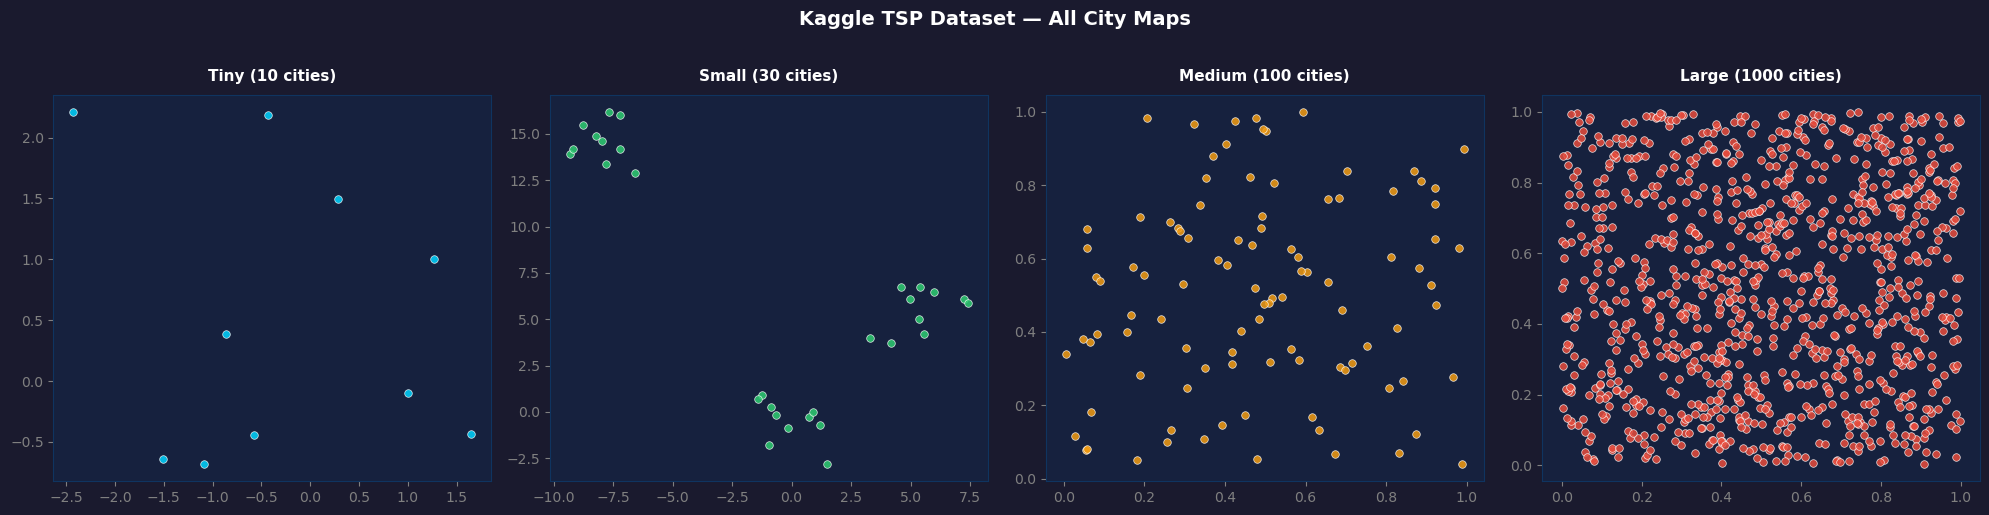


✅ All 4 datasets visualized.


In [7]:
# VISUALIZE: All 4 datasets side by side

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.patch.set_facecolor('#1a1a2e')

titles       = ['Tiny (10 cities)', 'Small (30 cities)',
                'Medium (100 cities)', 'Large (1000 cities)']
colors       = ['#00d4ff', '#2ecc71', '#f39c12', '#e74c3c']
dataset_list = [tiny_cities, small_cities, medium_cities, large_cities]

for ax, data, title, color in zip(axes, dataset_list, titles, colors):
    coords = np.array(data)
    ax.set_facecolor('#16213e')
    ax.scatter(coords[:, 0], coords[:, 1], color=color, s=30,
               edgecolors='white', linewidths=0.5, alpha=0.85)
    ax.set_title(title, color='white', fontsize=11, fontweight='bold', pad=10)
    ax.tick_params(colors='gray')
    ax.spines[:].set_color('#0f3460')

plt.suptitle("Kaggle TSP Dataset — All City Maps",
             color='white', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("\n✅ All 4 datasets visualized.")


## 3. Distance Matrix

We compute the **Euclidean distance** between every pair of cities:

$$d(i,j) = \sqrt{(x_i - x_j)^2 + (y_i - y_j)^2}$$


In [8]:
# FUNCTION: Compute Euclidean Distance Matrix

def compute_distance_matrix(coords):
    """
    Computes the full pairwise Euclidean distance matrix.

    Parameters:
        coords (list of tuples): City coordinates [(x0,y0), (x1,y1), ...]

    Returns:
        np.ndarray: Symmetric distance matrix of shape (n, n)
    """
    n    = len(coords)
    dist = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            dx = coords[i][0] - coords[j][0]
            dy = coords[i][1] - coords[j][1]
            dist[i][j] = math.sqrt(dx*dx + dy*dy)
    return dist

# Pre-compute distance matrices for all datasets
print("Computing distance matrices ...")
tiny_dist   = compute_distance_matrix(tiny_cities)
small_dist  = compute_distance_matrix(small_cities)
medium_dist = compute_distance_matrix(medium_cities)
large_dist  = compute_distance_matrix(large_cities)
print("✅ All distance matrices computed.")

# Display a 5x5 sample of the tiny distance matrix
print(f"\nDistance Matrix Sample — Tiny Dataset (5x5):")
print(f"\n{'':>8}", end="")
for j in range(5):
    print(f"  City {j}", end="")
print()
print("─" * 50)
for i in range(5):
    print(f"City {i}  |", end="")
    for j in range(5):
        print(f"  {tiny_dist[i][j]:>6.4f}", end="")
    print()


Computing distance matrices ...
✅ All distance matrices computed.

Distance Matrix Sample — Tiny Dataset (5x5):

          City 0  City 1  City 2  City 3  City 4
──────────────────────────────────────────────────
City 0  |  0.0000  2.1633  2.5658  0.4226  0.5588
City 1  |  2.1633  0.0000  1.7395  2.5621  1.6142
City 2  |  2.5658  1.7395  0.0000  2.7820  2.1185
City 3  |  0.4226  2.5621  2.7820  0.0000  0.9480
City 4  |  0.5588  1.6142  2.1185  0.9480  0.0000


---
## 4. Algorithm 1 — Nearest Neighbor (Greedy)

### How It Works
The **Nearest Neighbor** algorithm is a greedy heuristic for TSP:

1. Start at a chosen depot city
2. At each step, move to the **nearest unvisited city**
3. Repeat until all cities are visited
4. Return to the starting depot

### Example Sets
| Case | Dataset | Cities | Reason |
|---|---|---|---|
| **Best** | small.csv | 30 | Starting city yielding shortest route |
| **Average** | medium.csv | 100 | Starting city yielding mid-range route |
| **Worst** | large.csv | 1000 | Starting city yielding longest route |


In [9]:
# ALGORITHM 1: NEAREST NEIGHBOR (GREEDY)

def nearest_neighbor(dist_matrix, start_city):
    """
    Nearest Neighbor greedy algorithm for TSP.

    Parameters:
        dist_matrix (np.ndarray): Pairwise distance matrix
        start_city  (int)       : Index of the starting/depot city

    Returns:
        tour           (list) : Ordered city indices (returns to start)
        total_distance (float): Total tour distance
    """
    n         = len(dist_matrix)
    unvisited = list(range(n))
    unvisited.remove(start_city)

    tour           = [start_city]
    current        = start_city
    total_distance = 0

    # Greedily pick the nearest unvisited city at each step
    while unvisited:
        nearest = min(unvisited, key=lambda c: dist_matrix[current][c])
        total_distance += dist_matrix[current][nearest]
        tour.append(nearest)
        unvisited.remove(nearest)
        current = nearest

    # Return to starting depot to complete the tour
    total_distance += dist_matrix[current][start_city]
    tour.append(start_city)

    return tour, total_distance


def find_greedy_cases(dist_matrix):
    """
    Runs Nearest Neighbor from every starting city and
    identifies the best, average, and worst results.
    """
    results = []
    for start in range(len(dist_matrix)):
        tour, dist = nearest_neighbor(dist_matrix, start)
        results.append((dist, start, tour))
    results.sort(key=lambda x: x[0])
    best    = results[0]
    worst   = results[-1]
    average = results[len(results) // 2]
    return best, average, worst

print("✅ Nearest Neighbor algorithm defined.")


✅ Nearest Neighbor algorithm defined.


### Algorithm 1 — Run Best / Average / Worst Cases

In [22]:
# RUN NEAREST NEIGHBOR — 3 Example Sets

greedy_configs = [
    (small_cities,  small_dist,  "best",    "small.csv  — 30 Cities"),
    (medium_cities, medium_dist, "average", "medium.csv — 100 Cities"),
    (large_cities,  large_dist,  "worst",   "large.csv  — 1000 Cities"),
]

greedy_results = []

print("=" * 68)
print("  NEAREST NEIGHBOR (GREEDY) — Results Summary")
print("=" * 68)
print(f"  {'Case':<10} | {'Dataset':<25} | {'Cities':>6} | {'Distance':>12} | {'Time':>10}")
print(f"  {'─'*10}─{'─'*25}─{'─'*8}─{'─'*14}─{'─'*10}")

for coords, dist_matrix, case_label, dataset_name in greedy_configs:
    best, average, worst = find_greedy_cases(dist_matrix)
    case_map             = {"best": best, "average": average, "worst": worst}
    dist_val, start, _   = case_map[case_label]

    times = []
    for run in range(1, 6):
        t0             = time.perf_counter()
        tour, dist_val = nearest_neighbor(dist_matrix, start)
        t              = (time.perf_counter() - t0) * 1000
        times.append(t)
        print(f"    Run {run}: {t:.3f} ms")
    exec_time = min(times)
    print(f"    Minimum (reported): {exec_time:.3f} ms")

    greedy_results.append({
        "coords"   : coords,
        "tour"     : tour,
        "distance" : dist_val,
        "case"     : case_label,
        "dataset"  : dataset_name,
        "start"    : start,
        "exec_time": exec_time,
        "n_cities" : len(coords)
    })

    print(f"  {case_label.capitalize():<10} | {dataset_name:<25} | {len(coords):>6} | {dist_val:>12.6f} | {exec_time:>8.3f} ms")

print("=" * 68)

  NEAREST NEIGHBOR (GREEDY) — Results Summary
  Case       | Dataset                   | Cities |     Distance |       Time
  ───────────────────────────────────────────────────────────────────────
    Run 1: 0.521 ms
    Run 2: 0.530 ms
    Run 3: 0.516 ms
    Run 4: 0.483 ms
    Run 5: 0.508 ms
    Minimum (reported): 0.483 ms
  Best       | small.csv  — 30 Cities    |     30 |    64.616753 |    0.483 ms
    Run 1: 4.864 ms
    Run 2: 4.856 ms
    Run 3: 4.809 ms
    Run 4: 5.781 ms
    Run 5: 4.892 ms
    Minimum (reported): 4.809 ms
  Average    | medium.csv — 100 Cities   |    100 |     9.710002 |    4.809 ms
    Run 1: 462.246 ms
    Run 2: 470.790 ms
    Run 3: 472.708 ms
    Run 4: 478.574 ms
    Run 5: 471.110 ms
    Minimum (reported): 462.246 ms
  Worst      | large.csv  — 1000 Cities  |   1000 |    30.036921 |  462.246 ms


### Theoritical Vs. Experimental Time

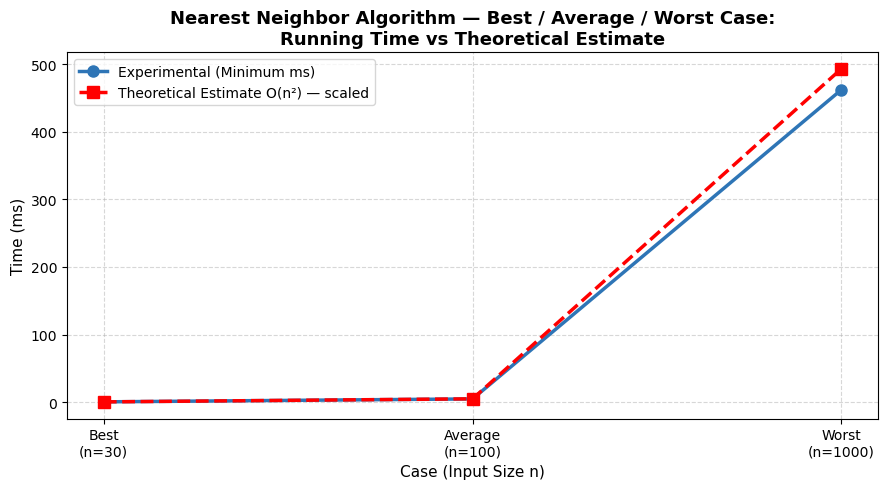

Saved: NN_Experimental_vs_Theoretical.png


In [1]:
import matplotlib.pyplot as plt

# Data
nn_cases        = ['Best\n(n=30)', 'Average\n(n=100)', 'Worst\n(n=1000)']
nn_experimental = [0.483, 4.809, 462.246]
nn_theoretical  = [30**2, 100**2, 1000**2]

# Normalize theoretical to same scale
ratio = sum(e/t for e,t in zip(nn_experimental, nn_theoretical)) / 3
nn_theoretical_scaled = [t * ratio for t in nn_theoretical]

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(nn_cases, nn_experimental,       color='#2E75B6', marker='o', linewidth=2.5, markersize=8, label='Experimental (Minimum ms)')
ax.plot(nn_cases, nn_theoretical_scaled, color='#FF0000', marker='s', linewidth=2.5, markersize=8, linestyle='--', label='Theoretical Estimate O(n²) — scaled')
ax.set_title('Nearest Neighbor Algorithm — Best / Average / Worst Case:\nRunning Time vs Theoretical Estimate', fontsize=13, fontweight='bold')
ax.set_xlabel('Case (Input Size n)', fontsize=11)
ax.set_ylabel('Time (ms)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('NN_Experimental_vs_Theoretical.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: NN_Experimental_vs_Theoretical.png")

### The running Time and Order of Growth Diagram for each case

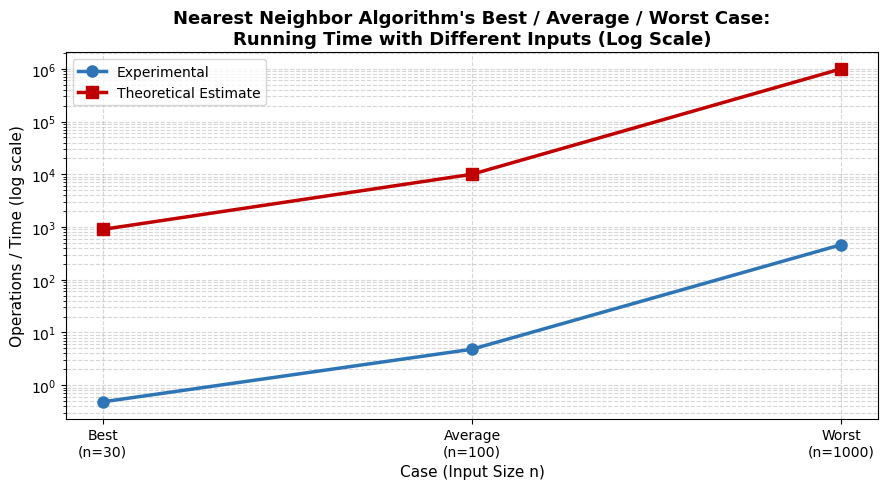

In [4]:
import matplotlib.pyplot as plt

# Data
nn_cases       = ['Best\n(n=30)', 'Average\n(n=100)', 'Worst\n(n=1000)']
nn_experimental = [0.483, 4.809, 462.246]
nn_theoretical  = [30**2, 100**2, 1000**2]  # 900, 10000, 1000000

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(nn_cases, nn_experimental,  color='#2E75B6', marker='o', linewidth=2.5, markersize=8, label='Experimental')
ax.plot(nn_cases, nn_theoretical,   color='#C00000', marker='s', linewidth=2.5, markersize=8, label='Theoretical Estimate')

ax.set_yscale('log')
ax.set_title("Nearest Neighbor Algorithm's Best / Average / Worst Case:\nRunning Time with Different Inputs (Log Scale)",
             fontsize=13, fontweight='bold')
ax.set_xlabel('Case (Input Size n)', fontsize=11)
ax.set_ylabel('Operations / Time (log scale)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5, which='both')
plt.tight_layout()
plt.savefig('NN_Running_Time_Diagram.png', dpi=150, bbox_inches='tight')
plt.show()

### Visualization Function

In [12]:
# VISUALIZATION HELPER FUNCTION

CASE_COLORS = {
    "best"   : "#2ecc71",
    "average": "#f39c12",
    "worst"  : "#e74c3c"
}

def plot_tour(coords, tour, title, total_dist, case_label, algo_name, exec_time=None):
    """
    Plots a TSP tour on a styled dark background map.
    """
    coords = np.array(coords)
    color  = CASE_COLORS[case_label]

    fig, ax = plt.subplots(figsize=(11, 8))
    fig.patch.set_facecolor('#1a1a2e')
    ax.set_facecolor('#16213e')

    # Draw tour edges
    for i in range(len(tour) - 1):
        x_vals = [coords[tour[i]][0], coords[tour[i+1]][0]]
        y_vals = [coords[tour[i]][1], coords[tour[i+1]][1]]
        ax.plot(x_vals, y_vals, color=color, alpha=0.55, linewidth=1.2, zorder=1)

    # Draw city nodes
    node_size = max(5, 60 - len(coords) // 20)
    ax.scatter(coords[:, 0], coords[:, 1], color='white', s=node_size,
               zorder=3, edgecolors=color, linewidths=0.8)

    # Highlight depot city with a star
    start = tour[0]
    ax.scatter(coords[start][0], coords[start][1], color=color,
               s=220, zorder=4, marker='*', edgecolors='white', linewidths=1.5)

    # Label cities for small sets
    if len(coords) <= 30:
        for i, (x, y) in enumerate(coords):
            ax.annotate(str(i), (x, y), textcoords="offset points",
                        xytext=(5, 5), fontsize=7.5, color='#cccccc')

    # Info box
    info_lines = [
        f"Total Distance : {total_dist:.6f}",
        f"Cities         : {len(coords)}",
        f"Start City     : {start}",
    ]
    if exec_time is not None:
        info_lines.append(f"Exec Time      : {exec_time*1000:.3f} ms")

    ax.text(0.02, 0.98, "\n".join(info_lines),
            transform=ax.transAxes, fontsize=9.5,
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.6', facecolor='#0f3460', alpha=0.85),
            color='white', fontfamily='monospace')

    case_display = case_label.capitalize() + " Case"
    ax.set_title(f"{algo_name}\n{case_display}  —  {title}",
                 fontsize=13, color='white', fontweight='bold', pad=14)
    ax.set_xlabel("X Coordinate", color='gray', fontsize=10)
    ax.set_ylabel("Y Coordinate", color='gray', fontsize=10)
    ax.tick_params(colors='gray')
    ax.spines[:].set_color('#0f3460')

    patch = mpatches.Patch(color=color,
                           label=f"{case_display}  |  Distance: {total_dist:.6f}")
    ax.legend(handles=[patch], loc='lower right', facecolor='#0f3460',
              edgecolor='gray', labelcolor='white', fontsize=9.5)

    plt.tight_layout()
    plt.show()

print("✅ Visualization function defined.")


✅ Visualization function defined.


### Algorithm 1 — Route Visualizations (Best / Average / Worst)


───────────────────────────────────────────────────────
  BEST CASE — small.csv  — 30 Cities
  Cities         : 30
  Start City     : 22
  Total Distance : 64.616753
  Execution Time : 0.541 ms
───────────────────────────────────────────────────────


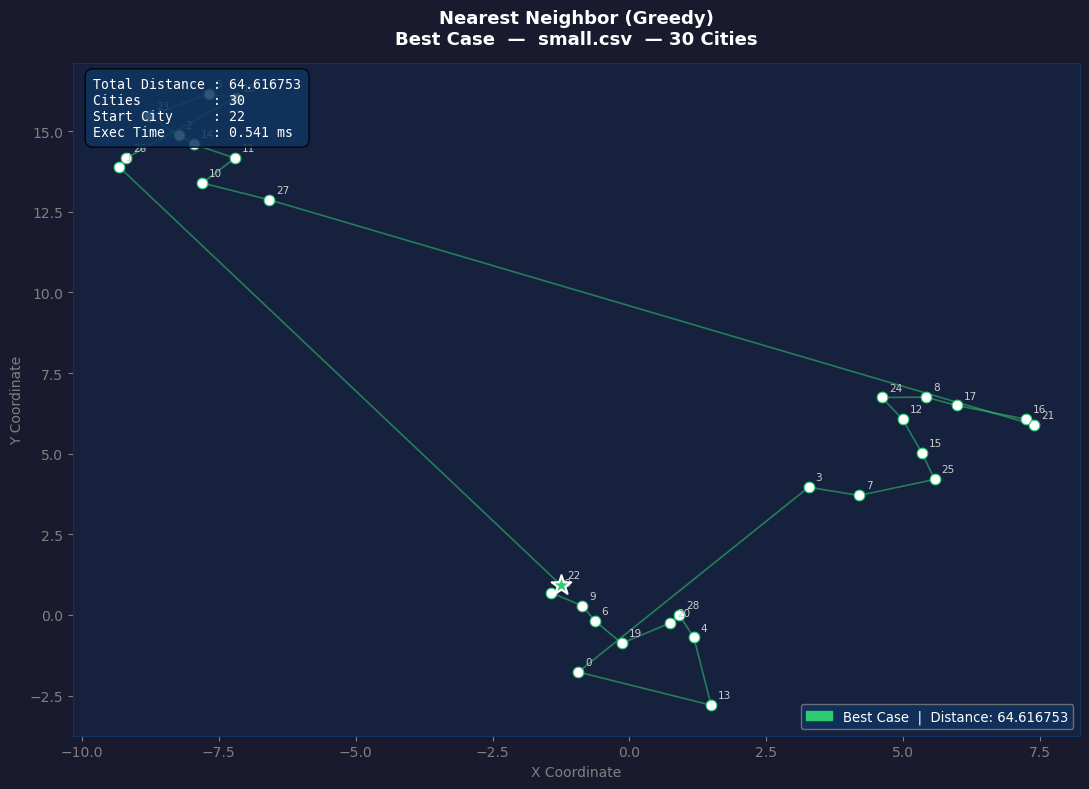


───────────────────────────────────────────────────────
  AVERAGE CASE — medium.csv — 100 Cities
  Cities         : 100
  Start City     : 38
  Total Distance : 9.710002
  Execution Time : 4.692 ms
───────────────────────────────────────────────────────


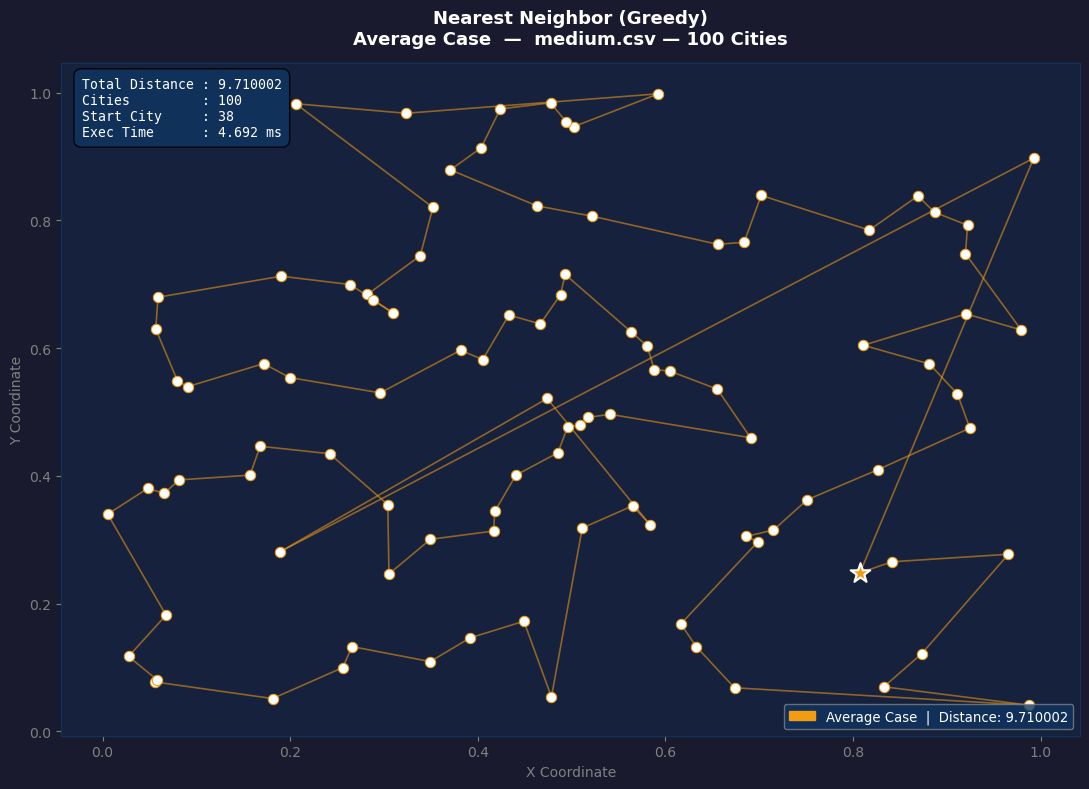


───────────────────────────────────────────────────────
  WORST CASE — large.csv  — 1000 Cities
  Cities         : 1000
  Start City     : 121
  Total Distance : 30.036921
  Execution Time : 482.344 ms
───────────────────────────────────────────────────────


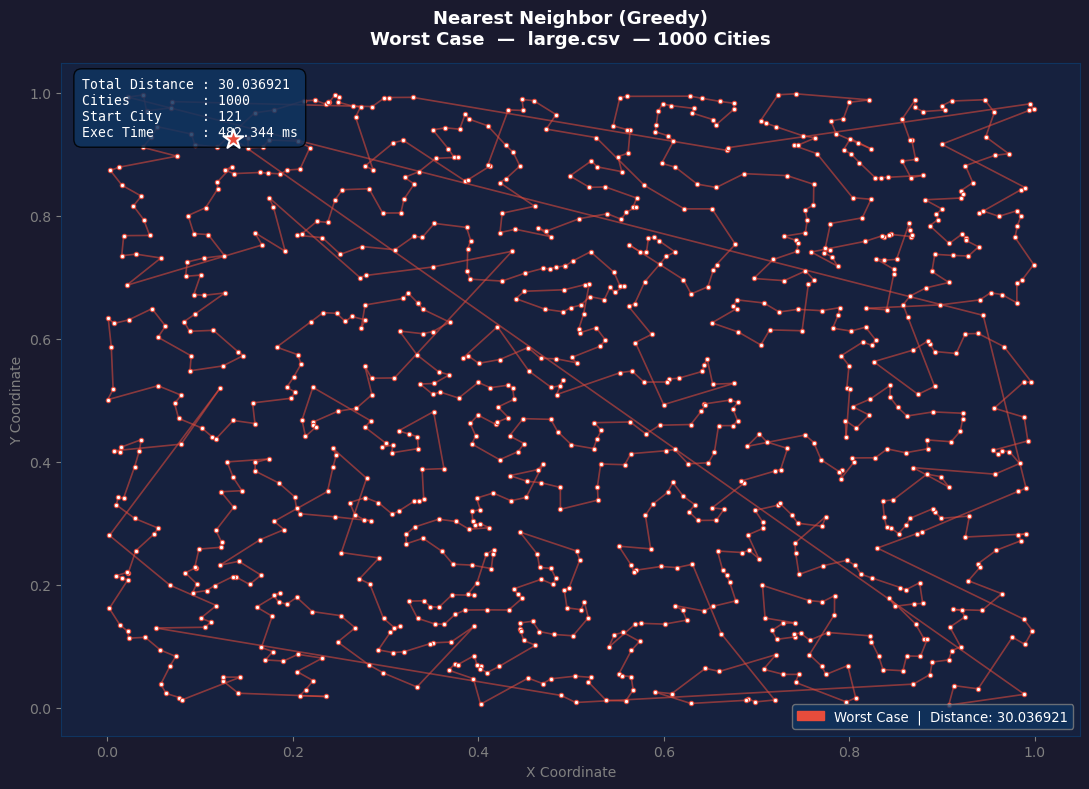

In [12]:
# VISUALIZE: Nearest Neighbor — 3 Cases

for result in greedy_results:
    print(f"\n{'─'*55}")
    print(f"  {result['case'].upper()} CASE — {result['dataset']}")
    print(f"  Cities         : {result['n_cities']}")
    print(f"  Start City     : {result['start']}")
    print(f"  Total Distance : {result['distance']:.6f}")
    print(f"  Execution Time : {result['exec_time']*1000:.3f} ms")
    print(f"{'─'*55}")
    plot_tour(result['coords'], result['tour'], result['dataset'],
              result['distance'], result['case'],
              "Nearest Neighbor (Greedy)", result['exec_time'])


---
## 5. Algorithm 2 — Held-Karp (Dynamic Programming)

### How It Works
The **Held-Karp** algorithm uses bitmask dynamic programming:

1. Represent visited cities as a **bitmask**
2. `dp[mask][i]` = minimum cost to reach city `i` visiting cities in `mask`
3. Build solutions from smaller subsets up to the full set
4. Reconstruct the optimal path via the parent table

### Example Sets
| Case | Dataset | Cities | Reason |
|---|---|---|---|
| **Best** | tiny.csv | 10 | Smallest input — fastest execution |
| **Average** | small.csv subset | 15 | Moderate execution time |
| **Worst** | medium.csv subset | 20 | Largest feasible — slowest execution |

> ⚠️ Running Held-Karp on all cities is computationally infeasible beyond ~20 cities due to exponential growth.


In [24]:
# ALGORITHM 2: HELD-KARP (DYNAMIC PROGRAMMING)

def held_karp(dist_matrix):
    """
    Held-Karp dynamic programming algorithm for TSP.
    Guarantees the mathematically optimal (shortest) tour.

    Parameters:
        dist_matrix (np.ndarray): Pairwise distance matrix (n x n)

    Returns:
        tour     (list) : Optimal ordered city indices
        min_cost (float): Minimum total tour distance
    """
    n   = len(dist_matrix)
    INF = float('inf')

    # dp[mask][i]     = min cost to reach city i visiting subset 'mask'
    # parent[mask][i] = previous city in the optimal path to i
    dp     = [[INF] * n for _ in range(1 << n)]
    parent = [[-1]  * n for _ in range(1 << n)]

    # Base case: start at city 0 (depot)
    dp[1][0] = 0

    # Fill DP table — build solutions for increasing subset sizes
    for mask in range(1, 1 << n):
        if not (mask & 1):        # Depot must always be in subset
            continue
        for last in range(n):
            if not (mask & (1 << last)):
                continue
            if dp[mask][last] == INF:
                continue
            for nxt in range(n):
                if mask & (1 << nxt):     # Skip already visited
                    continue
                new_mask = mask | (1 << nxt)
                new_cost = dp[mask][last] + dist_matrix[last][nxt]
                if new_cost < dp[new_mask][nxt]:
                    dp[new_mask][nxt] = new_cost
                    parent[new_mask][nxt] = last

    # Find optimal last city before returning to depot
    full_mask = (1 << n) - 1
    min_cost  = INF
    last_city = -1
    for i in range(1, n):
        cost = dp[full_mask][i] + dist_matrix[i][0]
        if cost < min_cost:
            min_cost  = cost
            last_city = i

    # Reconstruct optimal tour
    tour = []
    mask = full_mask
    cur  = last_city
    while cur != -1:
        tour.append(cur)
        prev = parent[mask][cur]
        mask ^= (1 << cur)
        cur   = prev
    tour.reverse()
    tour.append(tour[0])

    return tour, min_cost

print("✅ Held-Karp algorithm defined.")


✅ Held-Karp algorithm defined.


### Algorithm 2 — Run Best / Average / Worst Cases

In [25]:
# RUN HELD-KARP — 3 Example Sets

hk_configs = [
    (tiny_cities,   10, "best",    "tiny.csv   — 10 Cities (Full)"),
    (small_cities,  15, "average", "small.csv  — 15 Cities (Subset)"),
    (medium_cities, 20, "worst",   "medium.csv — 20 Cities (Subset)"),
]

hk_results = []

print("=" * 70)
print("  HELD-KARP (DYNAMIC PROGRAMMING) — Results Summary")
print("=" * 70)
print(f"  {'Case':<10} | {'Dataset':<30} | {'Cities':>6} | {'Distance':>12} | {'Time':>10}")
print(f"  {'─'*10}─{'─'*30}─{'─'*8}─{'─'*14}─{'─'*10}")

for base_coords, subset_size, case_label, dataset_name in hk_configs:
    subset_coords = base_coords[:subset_size]
    sub_dist      = compute_distance_matrix(subset_coords)

    times = []
    for run in range(1, 6):
        t0         = time.perf_counter()
        tour, dist = held_karp(sub_dist)
        t          = (time.perf_counter() - t0) * 1000
        times.append(t)
        print(f"    Run {run}: {t:.3f} ms")
    exec_time = min(times)
    print(f"    Minimum (reported): {exec_time:.3f} ms")

    hk_results.append({
        "coords"   : subset_coords,
        "tour"     : tour,
        "distance" : dist,
        "case"     : case_label,
        "dataset"  : dataset_name,
        "exec_time": exec_time,
        "n_cities" : subset_size
    })

    print(f"  {case_label.capitalize():<10} | {dataset_name:<30} | {subset_size:>6} | {dist:>12.6f} | {exec_time:>8.3f} ms")

print("=" * 70)

  HELD-KARP (DYNAMIC PROGRAMMING) — Results Summary
  Case       | Dataset                        | Cities |     Distance |       Time
  ────────────────────────────────────────────────────────────────────────────
    Run 1: 21.606 ms
    Run 2: 20.131 ms
    Run 3: 21.656 ms
    Run 4: 20.037 ms
    Run 5: 21.437 ms
    Minimum (reported): 20.037 ms
  Best       | tiny.csv   — 10 Cities (Full)  |     10 |    12.516978 |   20.037 ms
    Run 1: 1648.993 ms
    Run 2: 1662.887 ms
    Run 3: 2026.159 ms
    Run 4: 1659.035 ms
    Run 5: 1636.066 ms
    Minimum (reported): 1636.066 ms
  Average    | small.csv  — 15 Cities (Subset) |     15 |    52.649238 | 1636.066 ms
    Run 1: 98065.174 ms
    Run 2: 98426.541 ms
    Run 3: 99491.035 ms
    Run 4: 99022.463 ms
    Run 5: 98624.954 ms
    Minimum (reported): 98065.174 ms
  Worst      | medium.csv — 20 Cities (Subset) |     20 |     3.619913 | 98065.174 ms


### Theoritical Vs. Experimental Time

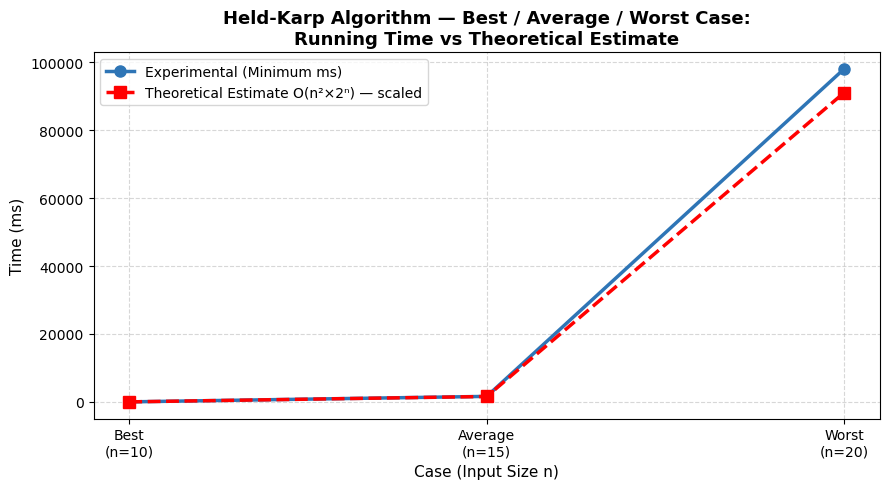

Saved: HK_Experimental_vs_Theoretical.png


In [2]:
import matplotlib.pyplot as plt

# Data
hk_cases        = ['Best\n(n=10)', 'Average\n(n=15)', 'Worst\n(n=20)']
hk_experimental = [20.037, 1636.066, 98065.174]
hk_theoretical  = [10**2 * 2**10, 15**2 * 2**15, 20**2 * 2**20]

# Normalize theoretical to same scale
ratio = sum(e/t for e,t in zip(hk_experimental, hk_theoretical)) / 3
hk_theoretical_scaled = [t * ratio for t in hk_theoretical]

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(hk_cases, hk_experimental,       color='#2E75B6', marker='o', linewidth=2.5, markersize=8, label='Experimental (Minimum ms)')
ax.plot(hk_cases, hk_theoretical_scaled, color='#FF0000', marker='s', linewidth=2.5, markersize=8, linestyle='--', label='Theoretical Estimate O(n²×2ⁿ) — scaled')
ax.set_title('Held-Karp Algorithm — Best / Average / Worst Case:\nRunning Time vs Theoretical Estimate', fontsize=13, fontweight='bold')
ax.set_xlabel('Case (Input Size n)', fontsize=11)
ax.set_ylabel('Time (ms)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('HK_Experimental_vs_Theoretical.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: HK_Experimental_vs_Theoretical.png")

### The running Time and Order of Growth Diagram for each case

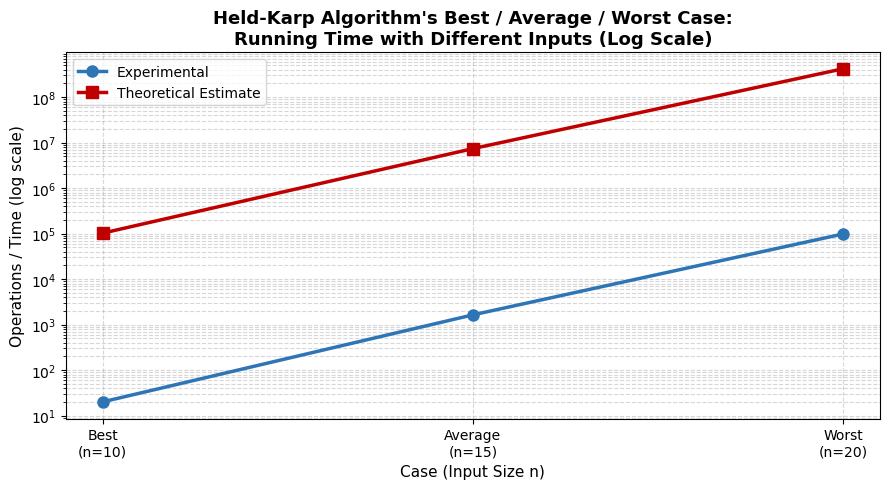

In [5]:
import matplotlib.pyplot as plt

# Data
hk_cases       = ['Best\n(n=10)', 'Average\n(n=15)', 'Worst\n(n=20)']
hk_experimental = [20.037, 1636.066, 98065.174]
hk_theoretical  = [10**2 * 2**10, 15**2 * 2**15, 20**2 * 2**20]  # 102400, 7372800, 419430400

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(hk_cases, hk_experimental,  color='#2E75B6', marker='o', linewidth=2.5, markersize=8, label='Experimental')
ax.plot(hk_cases, hk_theoretical,   color='#C00000', marker='s', linewidth=2.5, markersize=8, label='Theoretical Estimate')

ax.set_yscale('log')
ax.set_title("Held-Karp Algorithm's Best / Average / Worst Case:\nRunning Time with Different Inputs (Log Scale)",
             fontsize=13, fontweight='bold')
ax.set_xlabel('Case (Input Size n)', fontsize=11)
ax.set_ylabel('Operations / Time (log scale)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5, which='both')
plt.tight_layout()
plt.savefig('HK_Running_Time_Diagram.png', dpi=150, bbox_inches='tight')
plt.show()

### Algorithm 2 — Route Visualizations (Best / Average / Worst)


───────────────────────────────────────────────────────
  BEST CASE — tiny.csv   — 10 Cities (Full)
  Cities         : 10
  Total Distance : 12.516978
  Execution Time : 25.167 ms
───────────────────────────────────────────────────────


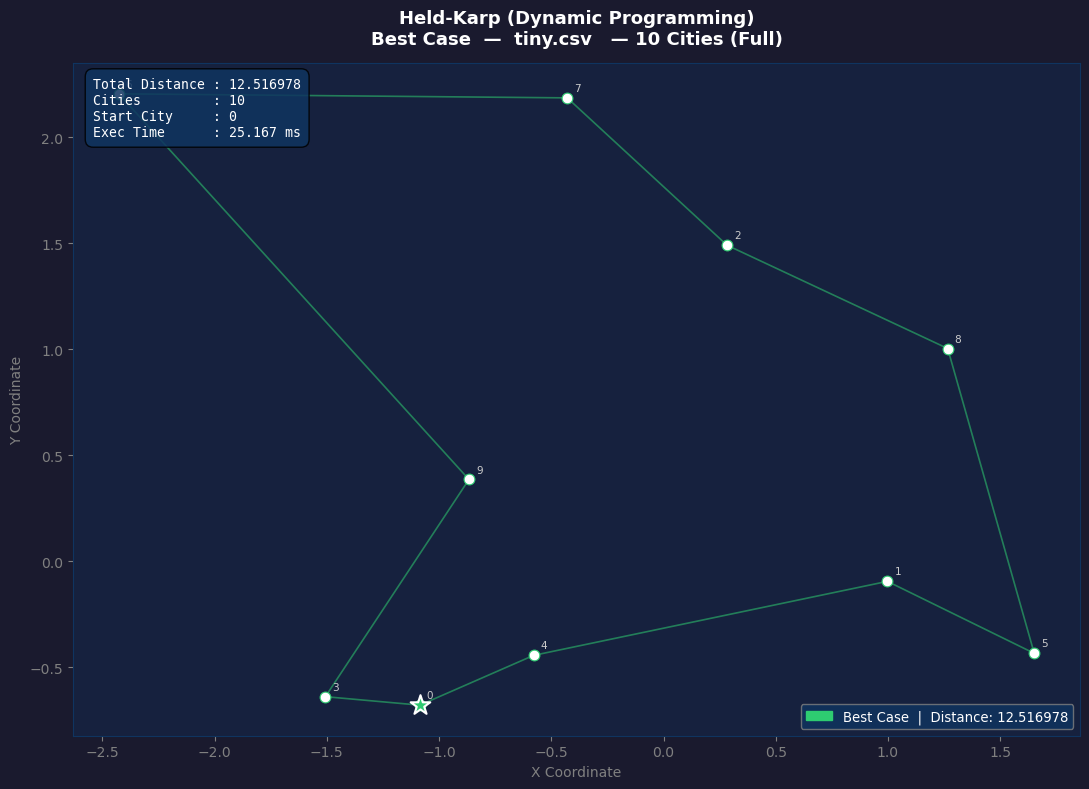


───────────────────────────────────────────────────────
  AVERAGE CASE — small.csv  — 15 Cities (Subset)
  Cities         : 15
  Total Distance : 52.649238
  Execution Time : 2024.896 ms
───────────────────────────────────────────────────────


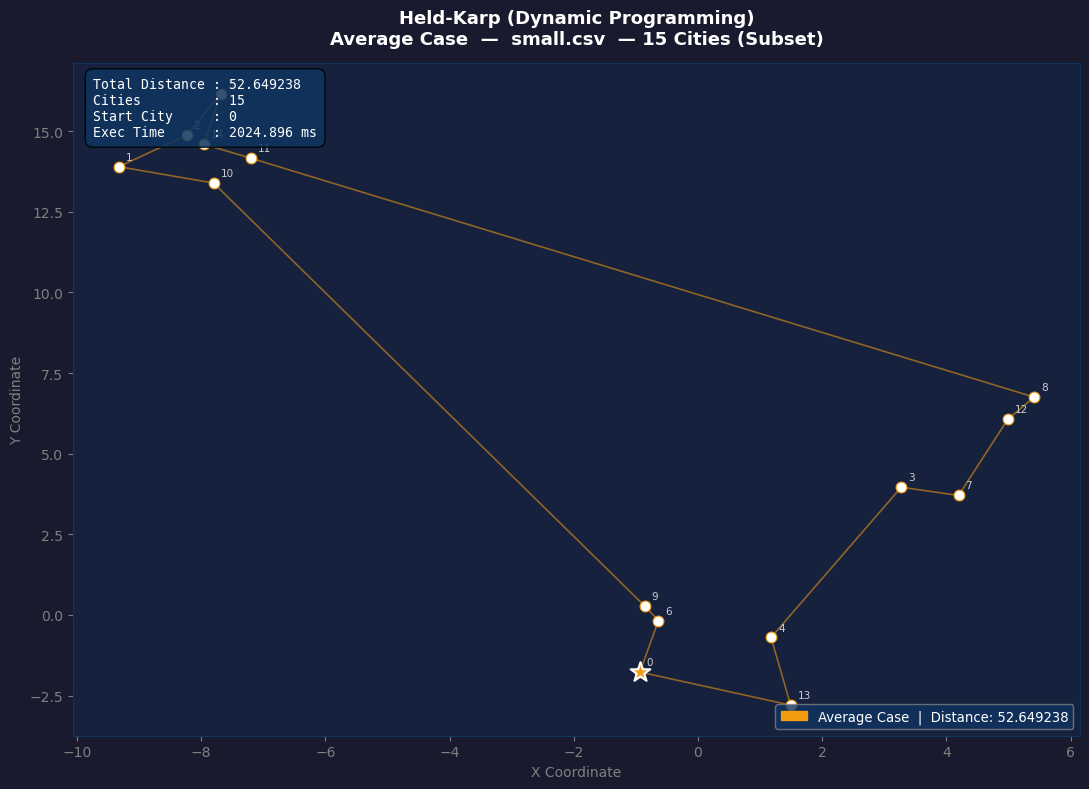


───────────────────────────────────────────────────────
  WORST CASE — medium.csv — 20 Cities (Subset)
  Cities         : 20
  Total Distance : 3.619913
  Execution Time : 102598.139 ms
───────────────────────────────────────────────────────


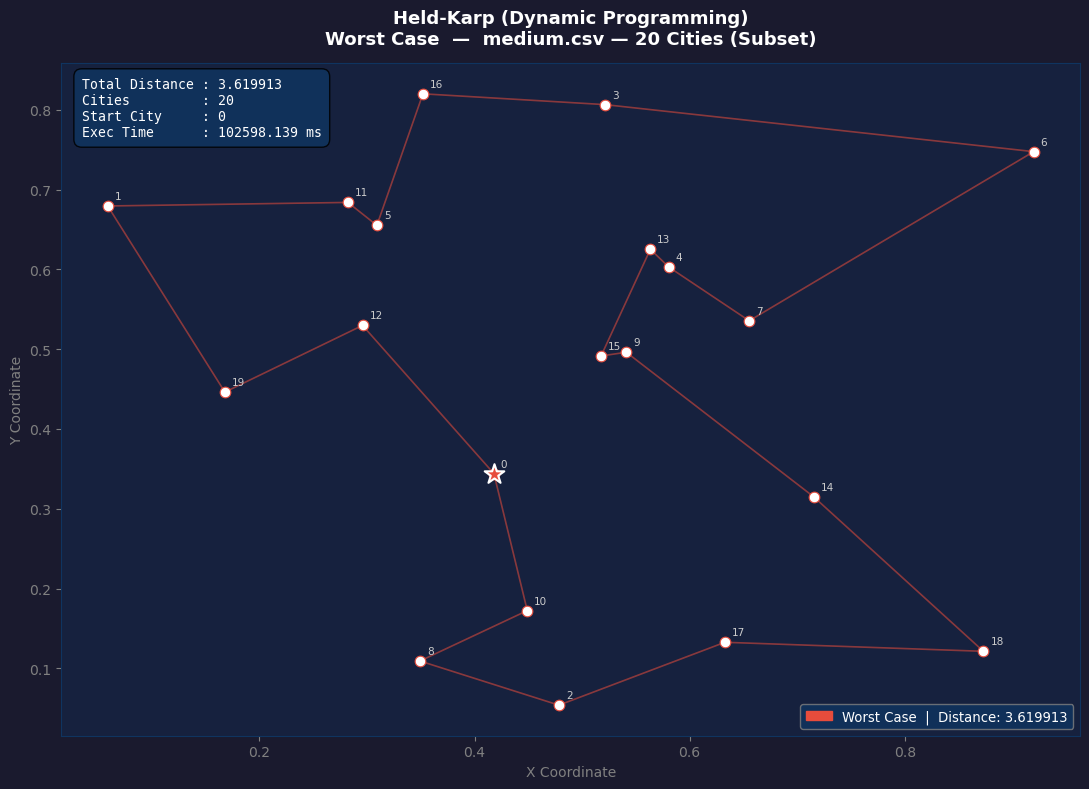

In [15]:
# VISUALIZE: Held-Karp — 3 Cases

for result in hk_results:
    print(f"\n{'─'*55}")
    print(f"  {result['case'].upper()} CASE — {result['dataset']}")
    print(f"  Cities         : {result['n_cities']}")
    print(f"  Total Distance : {result['distance']:.6f}")
    print(f"  Execution Time : {result['exec_time']*1000:.3f} ms")
    print(f"{'─'*55}")
    plot_tour(result['coords'], result['tour'], result['dataset'],
              result['distance'], result['case'],
              "Held-Karp (Dynamic Programming)", result['exec_time'])


### Space Complexity Comparision

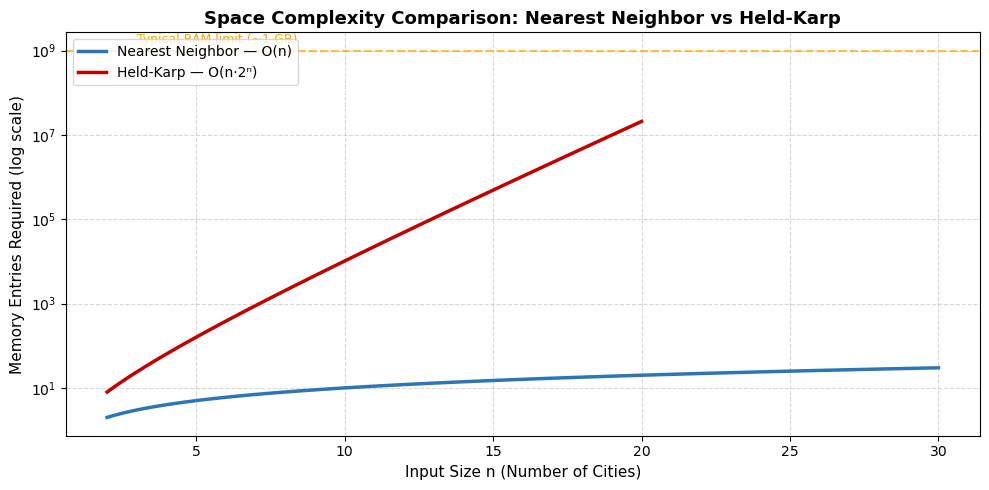

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Generate n values for smooth curves
n_nn = np.linspace(2, 30, 100)
n_hk = np.linspace(2, 20, 100)

# Space requirements
nn_space = n_nn                       # O(n)
hk_space = n_hk * (2 ** n_hk)         # O(n·2ⁿ)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_nn, nn_space, color='#2E75B6', linewidth=2.5, label='Nearest Neighbor — O(n)')
ax.plot(n_hk, hk_space, color='#C00000', linewidth=2.5, label='Held-Karp — O(n·2ⁿ)')

# Mark RAM limit
ax.axhline(y=1e9, color='orange', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(3, 1.5e9, 'Typical RAM limit (~1 GB)', fontsize=9, color='orange')

ax.set_yscale('log')
ax.set_title("Space Complexity Comparison: Nearest Neighbor vs Held-Karp",
             fontsize=13, fontweight='bold')
ax.set_xlabel('Input Size n (Number of Cities)', fontsize=11)
ax.set_ylabel('Memory Entries Required (log scale)', fontsize=11)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5, which='both')
plt.tight_layout()
plt.savefig('Space_Complexity_Comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Side by Side Comparision of Both Algorithims

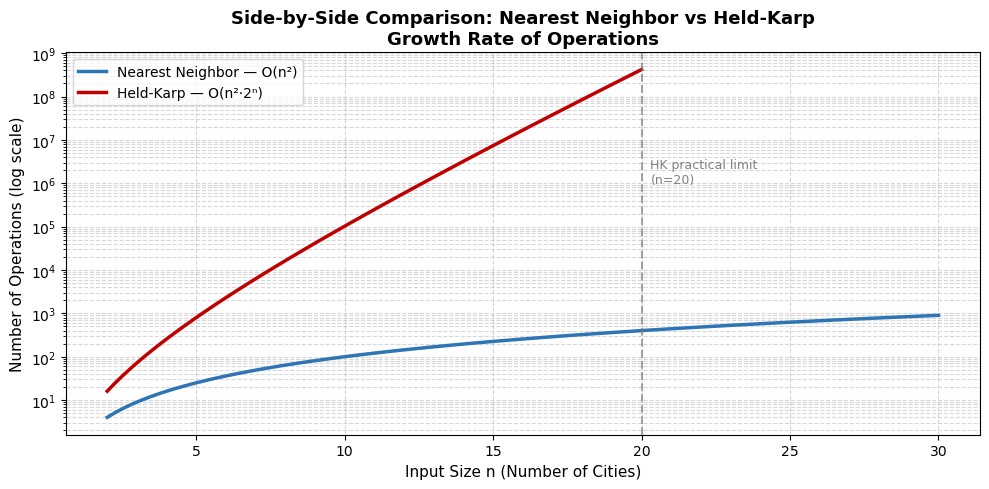

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Generate n values for smooth curves
n_nn = np.linspace(2, 30, 100)
n_hk = np.linspace(2, 20, 100)

# Theoretical operation counts
nn_ops = n_nn ** 2
hk_ops = (n_hk ** 2) * (2 ** n_hk)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_nn, nn_ops, color='#2E75B6', linewidth=2.5, label='Nearest Neighbor — O(n²)')
ax.plot(n_hk, hk_ops, color='#C00000', linewidth=2.5, label='Held-Karp — O(n²·2ⁿ)')

# Mark practical limit
ax.axvline(x=20, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(20.3, 1e6, 'HK practical limit\n(n=20)', fontsize=9, color='gray')

ax.set_yscale('log')
ax.set_title("Side-by-Side Comparison: Nearest Neighbor vs Held-Karp\nGrowth Rate of Operations",
             fontsize=13, fontweight='bold')
ax.set_xlabel('Input Size n (Number of Cities)', fontsize=11)
ax.set_ylabel('Number of Operations (log scale)', fontsize=11)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5, which='both')
plt.tight_layout()
plt.savefig('NN_vs_HK_Comparison.png', dpi=150, bbox_inches='tight')
plt.show()